In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [2]:
data = load_wine()

df = pd.DataFrame(data.data, columns=data.feature_names)

# Target = alcohol
y = df['alcohol']

# Features = everything except alcohol
X = df.drop(columns=['alcohol'])

print(df.head())  # always show dataset

   alcohol  malic_acid   ash  alcalinity_of_ash  magnesium  total_phenols  \
0    14.23        1.71  2.43               15.6      127.0           2.80   
1    13.20        1.78  2.14               11.2      100.0           2.65   
2    13.16        2.36  2.67               18.6      101.0           2.80   
3    14.37        1.95  2.50               16.8      113.0           3.85   
4    13.24        2.59  2.87               21.0      118.0           2.80   

   flavanoids  nonflavanoid_phenols  proanthocyanins  color_intensity   hue  \
0        3.06                  0.28             2.29             5.64  1.04   
1        2.76                  0.26             1.28             4.38  1.05   
2        3.24                  0.30             2.81             5.68  1.03   
3        3.49                  0.24             2.18             7.80  0.86   
4        2.69                  0.39             1.82             4.32  1.04   

   od280/od315_of_diluted_wines  proline  
0                  

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [4]:
model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [5]:
y_pred = model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("MSE:", mse)
print("R2 Score:", r2)

MSE: 0.185716087068525
R2 Score: 0.6889364317843809


In [6]:
print("\nEquation:")

for i, coef in enumerate(model.coef_):
    print(f"{coef:.4f} * {X.columns[i]}")

print("+", model.intercept_)


Equation:
0.1129 * malic_acid
0.2683 * ash
-0.0469 * alcalinity_of_ash
-0.0018 * magnesium
0.0920 * total_phenols
-0.0108 * flavanoids
-0.1243 * nonflavanoid_phenols
-0.1428 * proanthocyanins
0.1697 * color_intensity
0.4037 * hue
0.1193 * od280/od315_of_diluted_wines
0.0010 * proline
+ 10.975812731749558


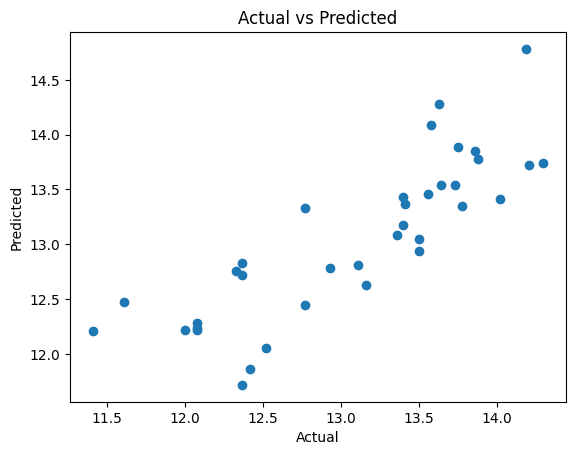

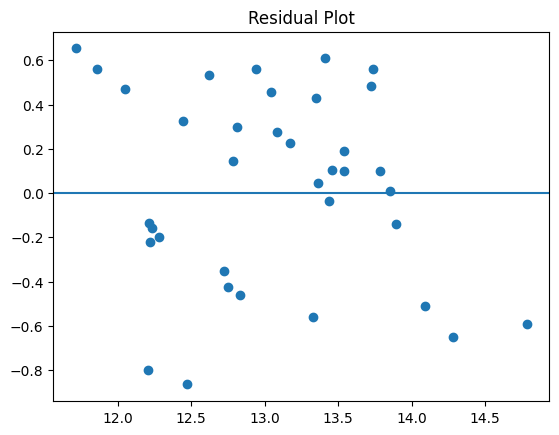

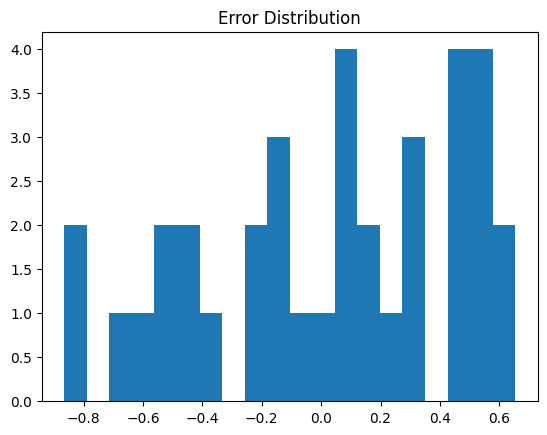

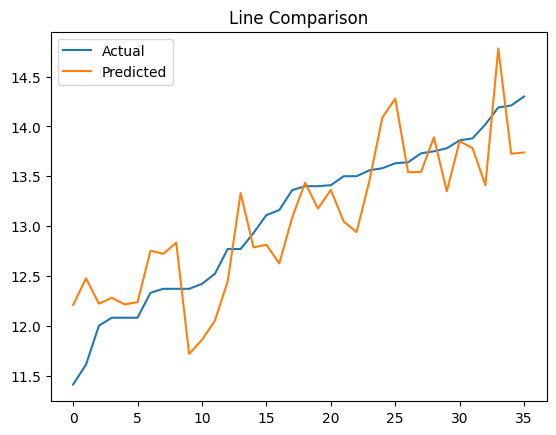

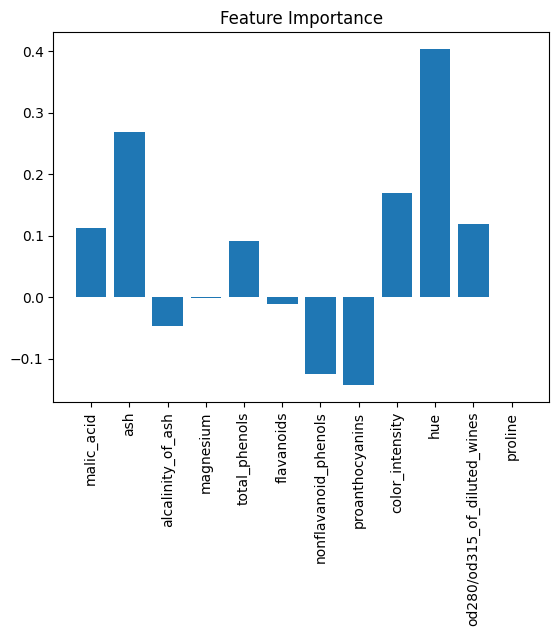

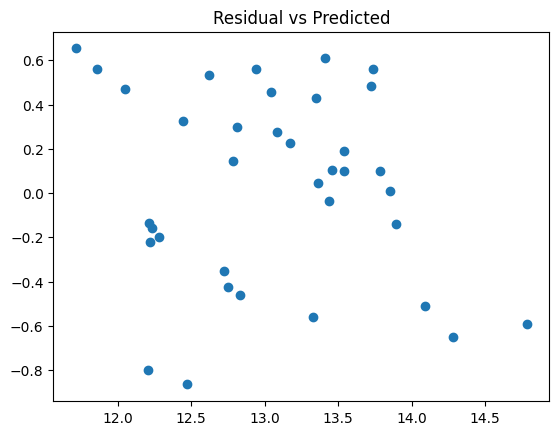

In [9]:
# 1. Actual vs Predicted
plt.figure()
plt.scatter(y_test, y_pred)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted")
plt.show()

# 2. Residual Plot
residuals = y_test - y_pred
plt.figure()
plt.scatter(y_pred, residuals)
plt.axhline(y=0)
plt.title("Residual Plot")
plt.show()

# 3. Error Distribution
plt.figure()
plt.hist(residuals, bins=20)
plt.title("Error Distribution")
plt.show()

# 4. Line Comparison
sorted_idx = np.argsort(y_test)
plt.figure()
plt.plot(np.array(y_test)[sorted_idx], label="Actual")
plt.plot(y_pred[sorted_idx], label="Predicted")
plt.legend()
plt.title("Line Comparison")
plt.show()

# 5. Feature Importance
plt.figure()
plt.bar(X.columns, model.coef_)
plt.xticks(rotation=90)
plt.title("Feature Importance")
plt.show()

# 6. Residual vs Predicted
plt.figure()
plt.scatter(y_pred, residuals)
plt.title("Residual vs Predicted")
plt.show()

In [8]:
print("\n--- Custom Input Prediction ---")

sample = [X_test.iloc[0].values]  # change values if needed

prediction = model.predict(sample)

print("Input:", sample)
print("Predicted Alcohol:", prediction)


--- Custom Input Prediction ---
Input: [array([3.10e+00, 2.56e+00, 1.52e+01, 1.16e+02, 2.70e+00, 3.03e+00,
       1.70e-01, 1.66e+00, 5.10e+00, 9.60e-01, 3.36e+00, 8.45e+02])]
Predicted Alcohol: [13.5398365]


c:\Users\Ekagr\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
